# **Heart Disease Classification**

**Dataset Introduction**

The dataset used in this project is the **Heart Disease Dataset**, which contains medical and demographic information about patients to help predict the likelihood of heart disease.

Each record represents a patient, and the goal is to classify whether they are likely to have heart disease (target = 1) or not (target = 0).


---
| Feature | Description |
|----------|--------------|
| **Age** | Age of the patient (in years) |
| **Sex** | Gender of the patient (`M` = Male, `F` = Female) |
| **ChestPainType** | Type of chest pain experienced — `TA` (Typical Angina), `ATA` (Atypical Angina), `NAP` (Non-Anginal Pain), `ASY` (Asymptomatic) |
| **RestingBP** | Resting blood pressure (in mm Hg) |
| **Cholesterol** | Serum cholesterol level (in mg/dL) |
| **FastingBS** | Fasting blood sugar indicator (`1` if FastingBS > 120 mg/dL, else `0`) |
| **RestingECG** | Resting electrocardiogram results — `Normal`, `ST`, or `LVH` |
| **MaxHR** | Maximum heart rate achieved during exercise |
| **ExerciseAngina** | Exercise-induced angina (`Y` = Yes, `N` = No) |
| **Oldpeak** | ST depression induced by exercise relative to rest |
| **ST_Slope** | Slope of the peak exercise ST segment — `Up`, `Flat`, or `Down` |
| **HeartDisease** | Target variable (`1` = presence of heart disease, `0` = absence) |

---
**Objective**

Build and evaluate machine learning models to classify heart disease presence using patient medical attributes.  
The workflow includes data exploration, preprocessing, feature encoding, model training, evaluation, and interpretability analysis.


## Imports & Setup


In [ ]:
import kagglehub
path=kagglehub.dataset_download("fedesoriano/heart-failure-prediction")

print("Path to dataset files:", path)


Using Colab cache for faster access to the 'heart-failure-prediction' dataset.
Path to dataset files: /kaggle/input/heart-failure-prediction


In [ ]:
import warnings
warnings.filterwarnings('ignore')


In [ ]:
import pandas as pd

df=pd.read_csv("/kaggle/input/heart-failure-prediction/heart.csv")
display(df.head())

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0


## Exploratory Data Analysis (EDA)


In [ ]:
print(df.info())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 918 entries, 0 to 917
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Age             918 non-null    int64  
 1   Sex             918 non-null    object 
 2   ChestPainType   918 non-null    object 
 3   RestingBP       918 non-null    int64  
 4   Cholesterol     918 non-null    int64  
 5   FastingBS       918 non-null    int64  
 6   RestingECG      918 non-null    object 
 7   MaxHR           918 non-null    int64  
 8   ExerciseAngina  918 non-null    object 
 9   Oldpeak         918 non-null    float64
 10  ST_Slope        918 non-null    object 
 11  HeartDisease    918 non-null    int64  
dtypes: float64(1), int64(6), object(5)
memory usage: 86.2+ KB
None


In [ ]:
df.describe()


,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease
count,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000
mean,53.510893,132.396514,198.799564,0.233115,136.809368,0.887364,0.553377
std,9.432617,18.514154,109.384145,0.423046,25.460334,1.066570,0.497414
min,28.000000,0.000000,0.000000,0.000000,60.000000,-2.600000,0.000000
25%,47.000000,120.000000,173.250000,0.000000,120.000000,0.000000,0.000000
50%,54.000000,130.000000,223.000000,0.000000,138.000000,0.600000,1.000000
75%,60.000000,140.000000,267.000000,0.000000,156.000000,1.500000,1.000000
max,77.000000,200.000000,603.000000,1.000000,202.000000,6.200000,1.000000


In [ ]:
df.isnull().sum()


,0
Age,0
Sex,0
ChestPainType,0
RestingBP,0
Cholesterol,0
FastingBS,0
RestingECG,0
MaxHR,0
ExerciseAngina,0
Oldpeak,0


## **Data Visulization**

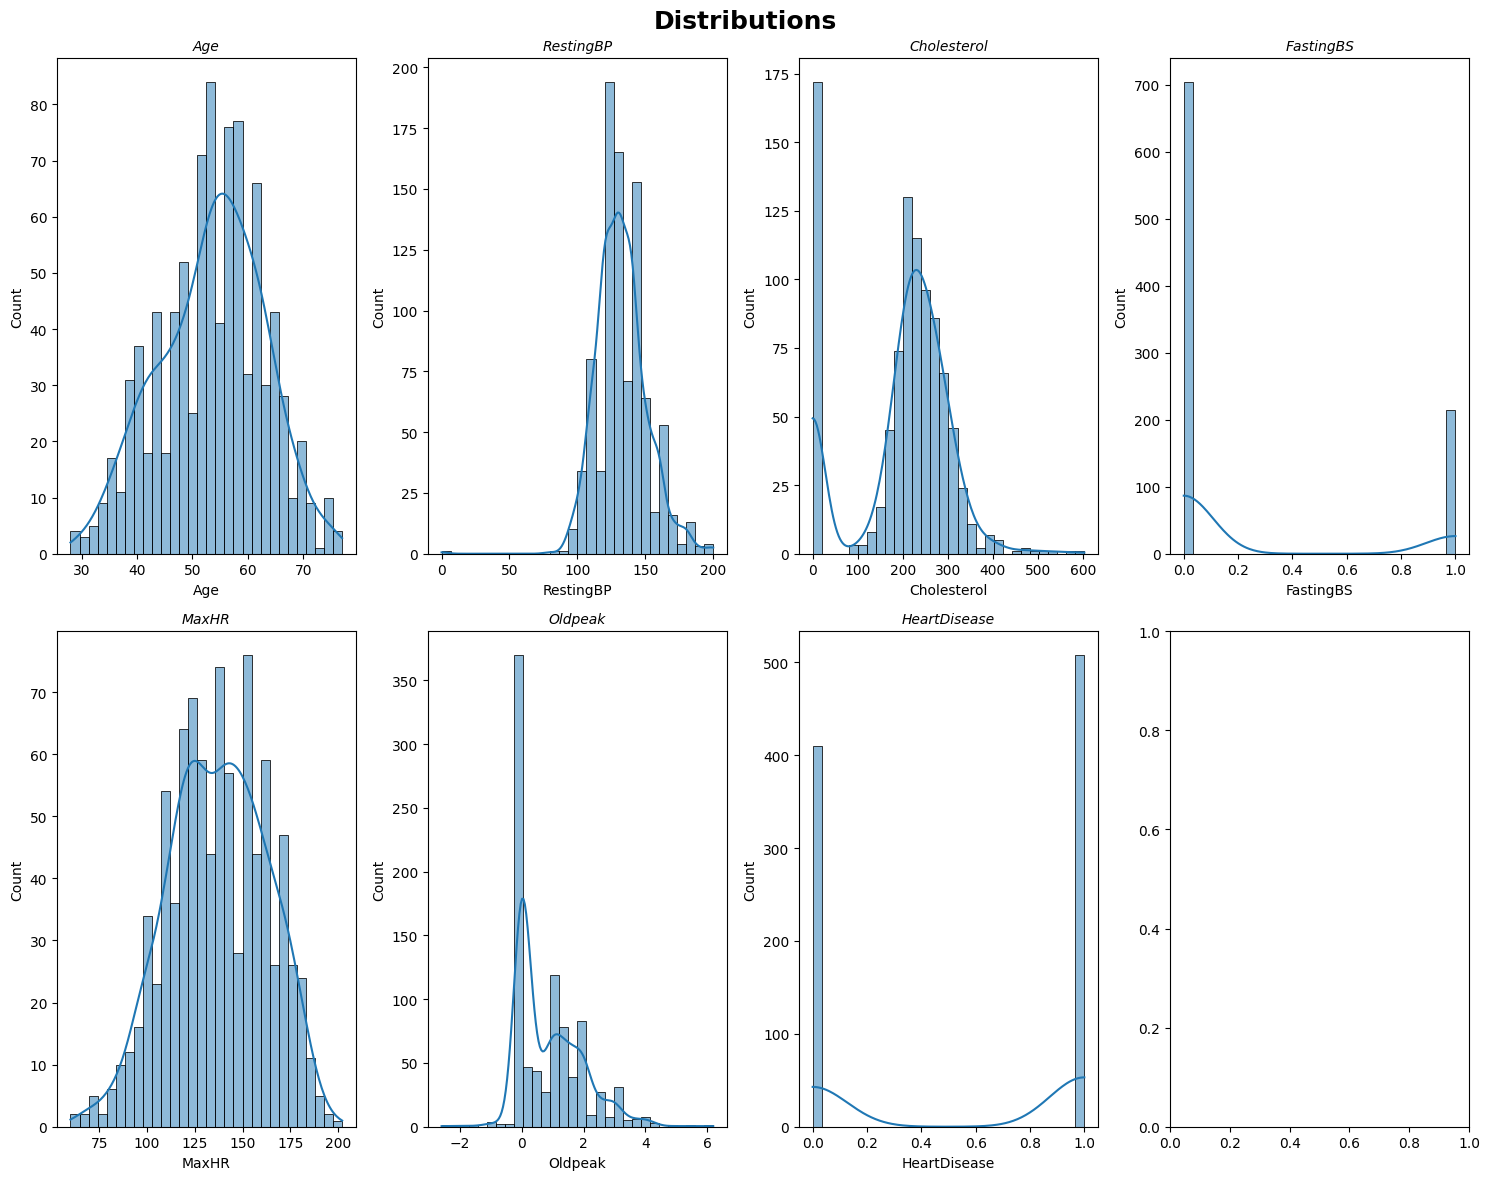

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

numeric_feature=df.select_dtypes(include=['int64','float64']).columns

fig ,axes = plt.subplots(nrows = 2, ncols = 4, figsize =(15,12))
fig.suptitle("Distributions", fontsize = 18, fontweight = "bold")

for i, col in enumerate(numeric_feature):
    row = i // 4
    col_idx = i % 4
    ax = axes[row,col_idx]
    sns.histplot(data = df, x =col , kde = True, ax =ax,bins=30)
    ax.set_title(col,fontsize = 10, fontstyle = "italic")
plt.tight_layout()
plt.show()



### **Box Plot**

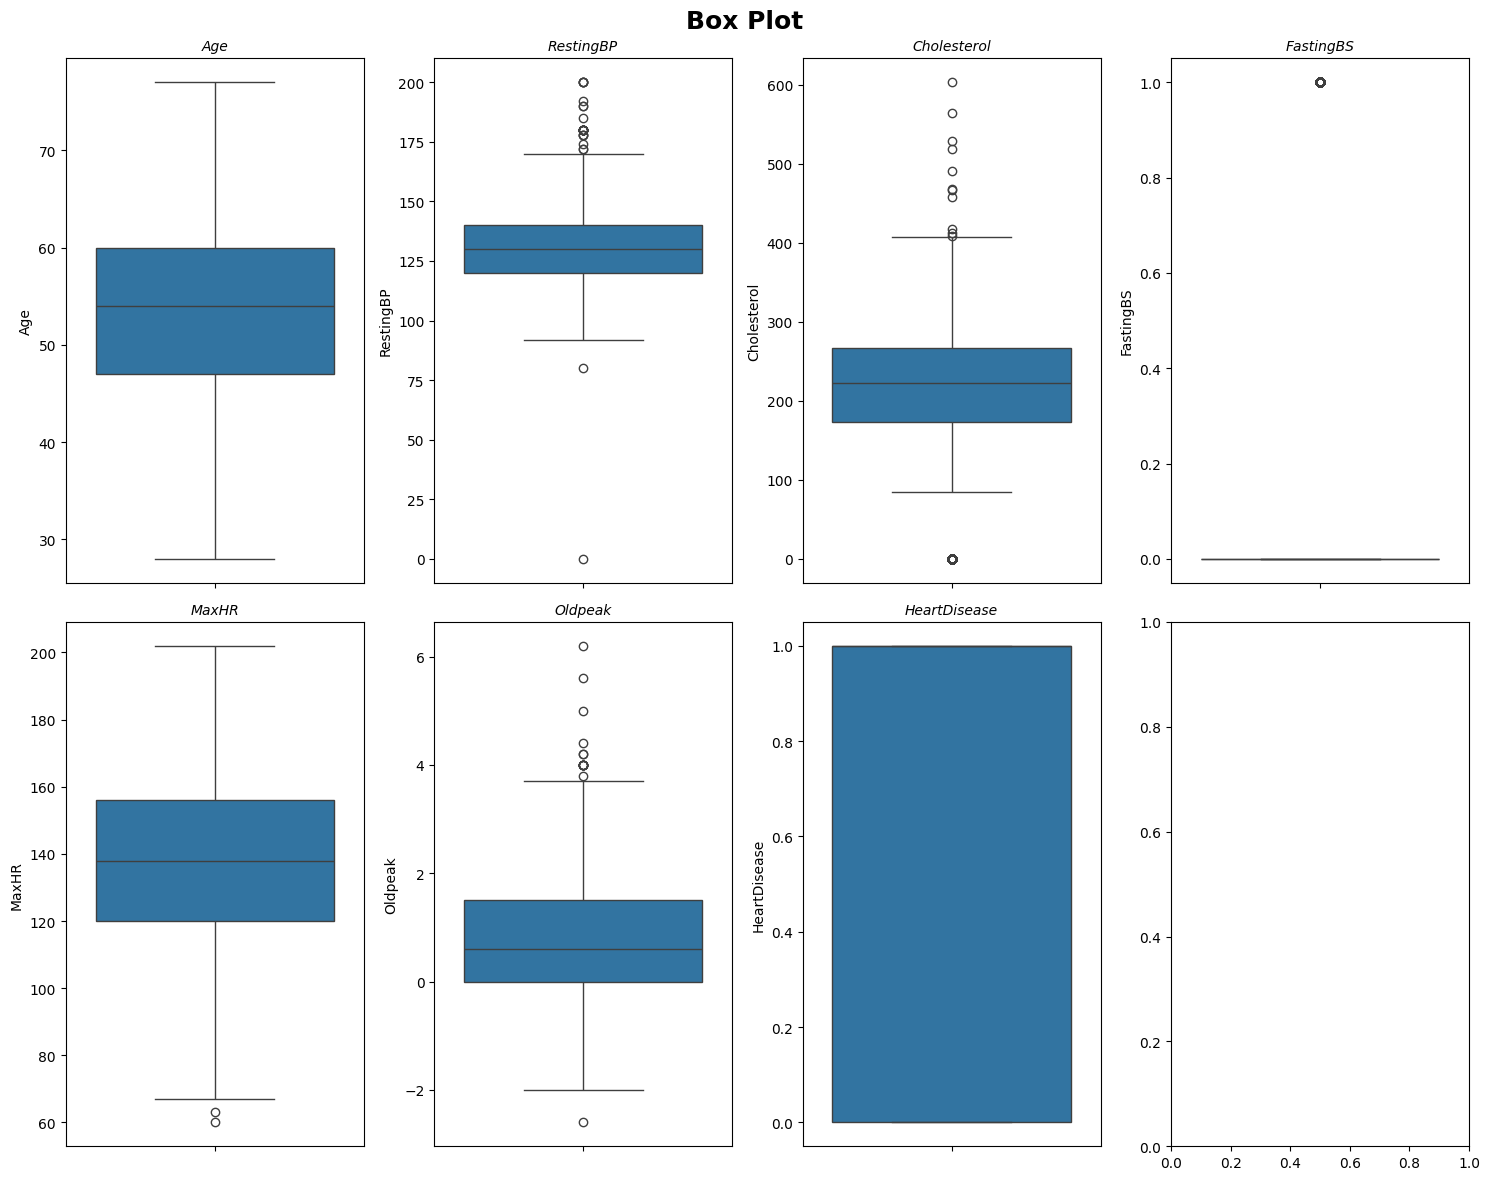

In [ ]:
fig ,axes = plt.subplots(nrows = 2, ncols = 4, figsize =(15,12))
fig.suptitle("Box Plot", fontsize = 18, fontweight = "bold")

for i, col in enumerate(numeric_feature):
    row = i // 4
    col_idx = i % 4
    ax = axes[row,col_idx]
    sns.boxplot(data = df, y =col , ax =ax)
    ax.set_title(col,fontsize = 10, fontstyle = "italic")
plt.tight_layout()
plt.show()

### **Outlier**


In [ ]:
def find_outlier_iqr(df,threshold=1.5):
    outlier_summary = {}

    for col in df.select_dtypes(include=['int64','float64']).columns:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1

        lower_bound = Q1- threshold * IQR
        upper_bound = Q3+ threshold * IQR

        outliers = df[ (df[col] < lower_bound) | (df[col] > upper_bound )]
        outlier_summary[col] = {
            "outlier_count": outliers.shape[0],
            "outiler_percentage": 100 * outliers.shape[0] / df.shape[0],
            "lower_bound": lower_bound,
            "upper_bound": upper_bound
        }
    return pd.DataFrame(outlier_summary)
find_outlier_iqr(df,2)


,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease
outlier_count,0.0,9.000000,8.00000,214.000000,0.0,3.000000,0.0
outiler_percentage,0.0,0.980392,0.87146,23.311547,0.0,0.326797,0.0
lower_bound,21.0,80.000000,-14.25000,0.000000,48.0,-3.000000,-2.0
upper_bound,86.0,180.000000,454.50000,0.000000,228.0,4.500000,3.0


### **Scatter plot**

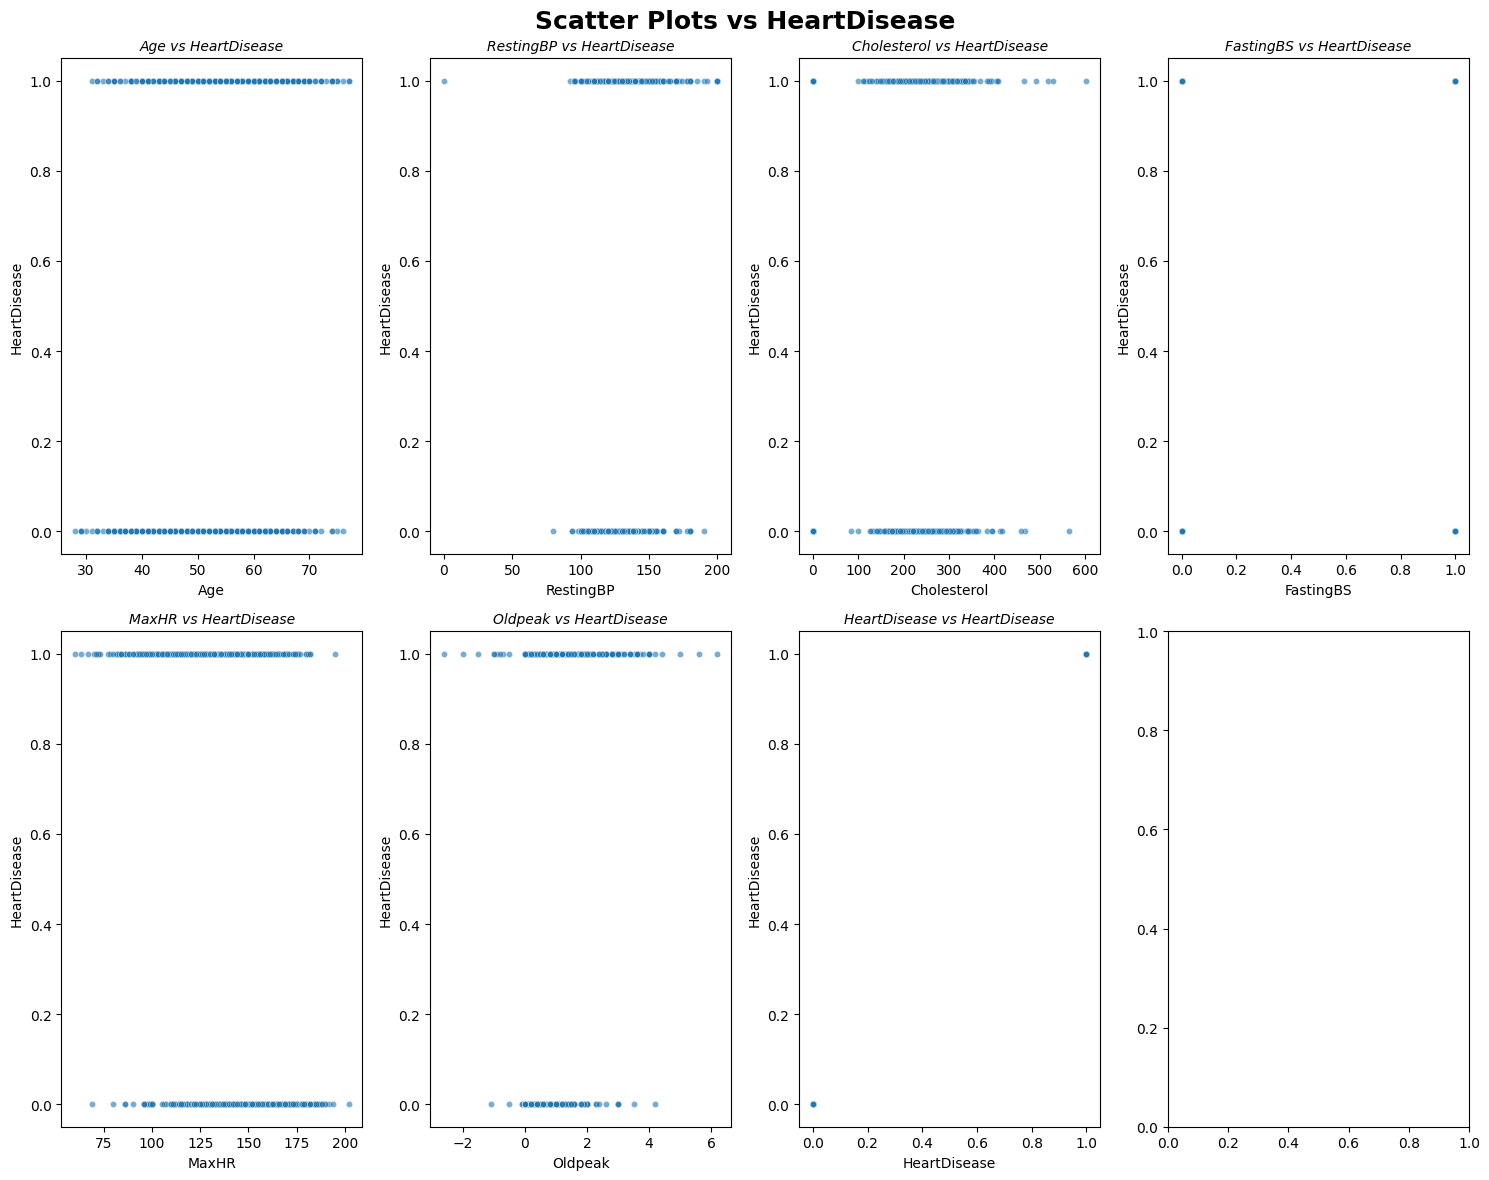

In [ ]:
fig, axes = plt.subplots(nrows=2, ncols=4, figsize=(15,12))
fig.suptitle("Scatter Plots vs HeartDisease", fontsize=18, fontweight="bold")

for i, col in enumerate(numeric_feature):
    row = i // 4
    col_idx = i % 4
    ax = axes[row, col_idx]
    sns.scatterplot(data=df, x=col, y="HeartDisease", ax=ax, s=20, alpha=0.6)
    ax.set_title(f"{col} vs HeartDisease", fontsize=10, fontstyle="italic")
plt.tight_layout()
plt.show()


### **Count Plot**

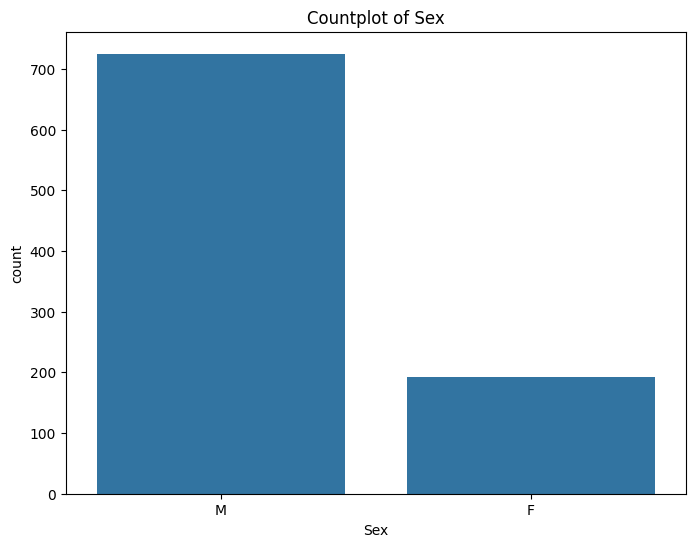

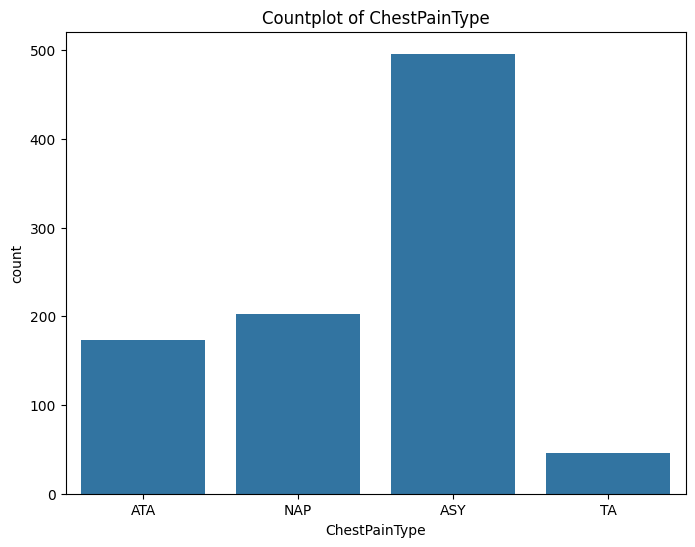

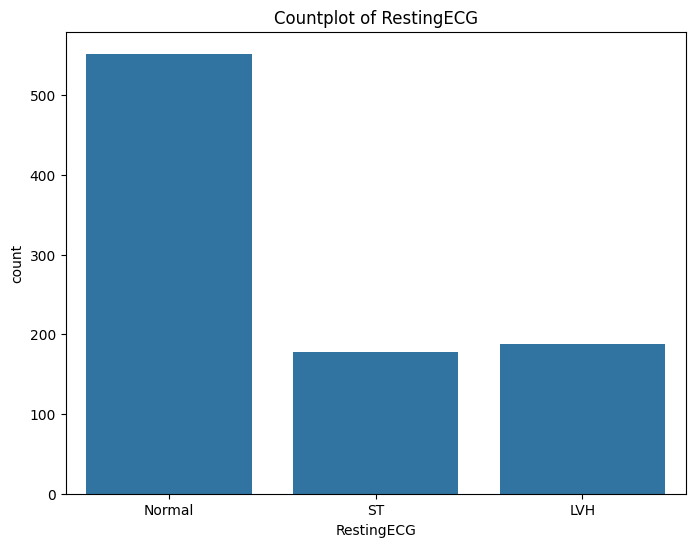

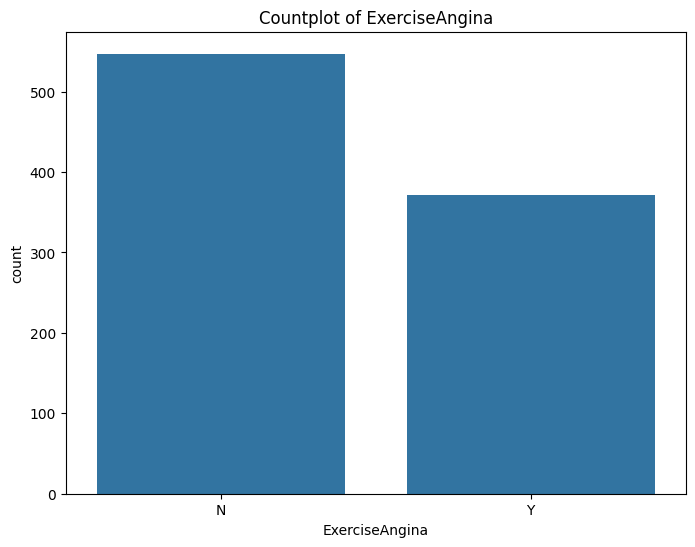

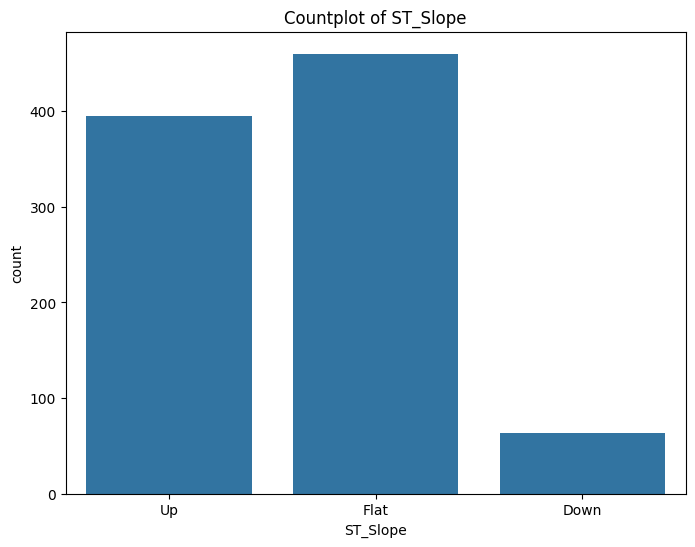

In [ ]:
object_feature=df.select_dtypes(include=['object']).columns
for col in object_feature:
  plt.figure(figsize=(8,6))
  sns.countplot(x=df[col])
  plt.title(f'Countplot of {col}')
  plt.show()


### **HeatMap**

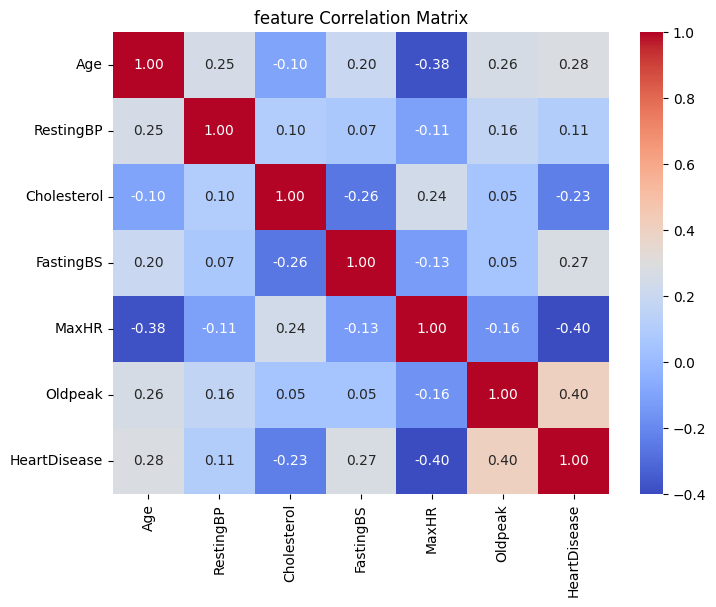

In [ ]:
plt.figure(figsize=(8,6))
sns.heatmap(df[numeric_feature].corr(),annot=True,cmap='coolwarm',fmt='.2f')
plt.title('feature Correlation Matrix')
plt.show()


## Train/Validation Split


In [ ]:
target=['HeartDisease']
x=df.drop(target,axis=1)
y=df[target]


In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder , MinMaxScaler
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, classification_report,mean_absolute_error , mean_squared_error , r2_score, precision_recall_fscore_support
from sklearn.preprocessing import LabelEncoder
import numpy as np

x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=42)

## **Preprocessing**

In [ ]:
num_train= Pipeline([
    ('imputer' , SimpleImputer(strategy="mean")),
    ('scaler' , StandardScaler())
])

object_train = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder' , OneHotEncoder(handle_unknown='ignore'))
])

process_data = ColumnTransformer([
    ('number', num_train,numeric_feature),
    ('object', object_train , object_feature)
])

In [ ]:
numeric_feature_for_transformer = [col for col in numeric_feature if col != 'HeartDisease']

process_data_dense = ColumnTransformer([
    ('number', num_train, numeric_feature_for_transformer),
    ('object', OneHotEncoder(handle_unknown='ignore', sparse_output=False), object_feature)
])


process_data_sparse = ColumnTransformer([
    ('number', num_train, numeric_feature_for_transformer),
    ('object', OneHotEncoder(handle_unknown='ignore'), object_feature)
])




## **Model pipelines**

In [ ]:
model_pipelines = {
    "LogisticRegression": Pipeline([
        ("preprocess", process_data_sparse),
        ("clf", LogisticRegression(max_iter=1000, class_weight="balanced"))
    ]),
    "DecisionTree": Pipeline([
        ("preprocess", process_data_sparse),
        ("clf", DecisionTreeClassifier(random_state=42, class_weight="balanced"))
    ]),
    "RandomForest": Pipeline([
        ("preprocess", process_data_sparse),
        ("clf", RandomForestClassifier(
            n_estimators=300, random_state=42, class_weight="balanced", n_jobs=-1
        ))
    ]),
    "SVM": Pipeline([
        ("preprocess", process_data_sparse),
        ("clf", SVC(kernel="rbf", probability=True, class_weight="balanced", random_state=42))
    ]),
    "kNN": Pipeline([
        ("preprocess", process_data_sparse),
        ("clf", KNeighborsClassifier(n_neighbors=5))
    ]),
    "NaiveBayes": Pipeline([
        ("preprocess", process_data_dense),
        ("clf", GaussianNB())
    ]),
}


## **Train the model**

In [ ]:
le = LabelEncoder()
y_train_enc = le.fit_transform(np.asarray(y_train).ravel())
y_test_enc  = le.transform(np.asarray(y_test).ravel())


rows = []
reports = {}
for name, pipe in model_pipelines.items():

    pipe.fit(x_train, y_train_enc)
    y_pred = pipe.predict(x_test)

    acc = accuracy_score(y_test_enc, y_pred)
    prec_w, rec_w, f1_w, _ = precision_recall_fscore_support(
        y_test_enc, y_pred, average="weighted", zero_division=0
    )
    rows.append([name, acc, prec_w, rec_w, f1_w])


    reports[name] = classification_report(y_test_enc, y_pred, zero_division=0)

results_df = pd.DataFrame(
    rows, columns=["Model", "Accuracy", "Precision_w", "Recall_w", "F1_w"]
).sort_values("F1_w", ascending=False).reset_index(drop=True)

print(results_df.to_string(index=True))
best_model_name = results_df.iloc[0]["Model"]
print("\nBest model by F1_w:", best_model_name)
print("\nClassification report (best):\n", reports[best_model_name])


                Model  Accuracy  Precision_w  Recall_w      F1_w
0        RandomForest  0.880435     0.880435  0.880435  0.880435
1          NaiveBayes  0.864130     0.872000  0.864130  0.864978
2                 kNN  0.864130     0.867953  0.864130  0.864787
3                 SVM  0.858696     0.860400  0.858696  0.859139
4  LogisticRegression  0.853261     0.859006  0.853261  0.854091
5        DecisionTree  0.809783     0.815807  0.809783  0.810859

Best model by F1_w: RandomForest

Classification report (best):
               precision    recall  f1-score   support

           0       0.86      0.86      0.86        77
           1       0.90      0.90      0.90       107

    accuracy                           0.88       184
   macro avg       0.88      0.88      0.88       184
weighted avg       0.88      0.88      0.88       184



## Conclusion

This project successfully implemented a complete **machine learning pipeline** to predict the presence of heart disease using structured clinical data.  
Multiple classification algorithms were evaluated — **RandomForest, Naïve Bayes, kNN, SVM, Logistic Regression,** and **Decision Tree** — to determine the most effective predictive model.

---

### Model Comparison Summary
| Model | Accuracy | Weighted Precision | Weighted Recall | Weighted F1-Score |
|:------|:----------:|:------------------:|:----------------:|:------------------:|
| RandomForest | **0.88** | **0.88** | **0.88** | **0.88** |
| Naïve Bayes | 0.86 | 0.87 | 0.86 | 0.86 |
| kNN | 0.86 | 0.86 | 0.86 | 0.86 |
| SVM | 0.86 | 0.86 | 0.86 | 0.86 |
| Logistic Regression | 0.85 | 0.86 | 0.85 | 0.85 |
| Decision Tree | 0.81 | 0.81 | 0.81 | 0.81 |

---

### Classification Report (Best Model: RandomForest)
| Class | Precision | Recall | F1-Score | Support |
|:------|:-----------:|:--------:|:-----------:|:--------:|
| 0 (No Disease) | 0.86 | 0.86 | 0.86 | 77 |
| 1 (Disease) | 0.90 | 0.90 | 0.90 | 107 |
| **Accuracy** |  |  | **0.88** | 184 |
| **Macro Avg** | 0.88 | 0.88 | 0.88 | 184 |
| **Weighted Avg** | 0.88 | 0.88 | 0.88 | 184 |

---

### Interpretation and Insights
- The **RandomForest Classifier** achieved the highest and most balanced performance across all metrics (Accuracy = 0.88, Precision = 0.88, Recall = 0.88).  
- The model shows **strong generalization** and consistent prediction power for both positive and negative cases.  
- Class 1 (patients with heart disease) achieved high recall (0.90), indicating effective detection of at-risk patients.  
- Class 0 (no heart disease) maintained comparable precision and recall, minimizing false positives.

---

### Future Enhancements
- Conduct **hyperparameter tuning** to further optimize RandomForest performance.  
- Implement **cross-validation** for more stable generalization metrics.  
- Explore **feature importance analysis** and **SHAP explainability** to identify critical clinical indicators.  
- Extend the system for **real-world deployment** as a diagnostic support tool with REST API integration or a web interface.  
- Experiment with **ensemble stacking** or **deep learning** architectures for advanced benchmarking.

---

**Final Verdict:**  
The RandomForest classifier achieved **88% overall accuracy** and delivered a balanced precision–recall tradeoff, confirming its effectiveness as the best-performing model.  

